Cell 1 — Import & Setup

In [1]:
# Cell 1 — Import & Setup
import os
import sys
from pathlib import Path

# Ép lùi thư mục làm việc về gốc dự án nếu đang ở trong thư mục notebooks
if Path(os.getcwd()).name == "notebooks":
    os.chdir("..")

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.utils   import load_config, set_seed, get_device
from src.dataset import get_dataloaders
from src.evaluate import (load_and_evaluate, collect_predictions,
                           plot_confusion_matrix, plot_roc_curve,
                           plot_per_class_accuracy)

# ── Setup ─────────────────────────────────────────────────────── #
cfg    = load_config("config.yaml") 
set_seed(cfg["training"]["seed"])
device = get_device()

# Ép num_workers về 0 để tránh deadlock trên Windows khi chạy Notebook
cfg['training']['num_workers'] = 0

FIG_DIR     = Path("outputs/figures")
REPORT_DIR  = Path("outputs/reports")
FIG_DIR.mkdir(parents=True,    exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ SETUP HOÀN TẤT")
print(f"  Thư mục hoạt động hiện tại : {os.getcwd()}")
print(f"  Kiến trúc mô hình sử dụng  : {cfg['model']['architecture']}")
print(f"  Thiết bị phần cứng tính    : {device}")

[Device] Đang dùng: cpu
✅ SETUP HOÀN TẤT
  Thư mục hoạt động hiện tại : c:\Users\Thang\source\repos\brain-tumor-classification
  Kiến trúc mô hình sử dụng  : resnet18
  Thiết bị phần cứng tính    : cpu


Cell 2 — Load Data & Model

In [2]:
print("\n[Data] Đang load...")
train_loader, val_loader, test_loader, class_to_idx, idx_to_class = get_dataloaders(cfg)

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(f"   Classes   : {class_names}")
print(f"   Test size : {len(test_loader.dataset)} ảnh")

# ── Load best checkpoint ──────────────────────────────────────── #
print("\n[Model] Đang load checkpoint...")
from src.model import build_model

ckpt_path = cfg["paths"]["best_model"] # Đã sửa: Không cộng chuỗi "../" thủ công
if not Path(ckpt_path).exists():
    raise FileNotFoundError(f"Không tìm thấy checkpoint tại {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)
model      = build_model(cfg).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"   ✅ Loaded epoch {checkpoint['epoch']} — val_loss: {checkpoint['val_loss']:.4f} | val_acc: {checkpoint['val_acc']:.2f}%")


[Data] Đang load...
[Dataset] Quét thư mục Training...
  [glioma] 1321 ảnh
  [meningioma] 1339 ảnh
  [notumor] 1595 ảnh
  [pituitary] 1457 ảnh
  → Tổng: 5712 ảnh

[Phân bố dữ liệu]
  glioma               1321 ảnh
  meningioma           1339 ảnh
  notumor              1595 ảnh
  pituitary            1457 ảnh

[Dataset] Quét thư mục Testing...
  [glioma] 300 ảnh
  [meningioma] 306 ảnh
  [notumor] 405 ảnh
  [pituitary] 300 ảnh
  → Tổng: 1311 ảnh

[Split] Train: 4855 | Val: 857 | Test: 1311
   Classes   : ['glioma', 'meningioma', 'notumor', 'pituitary']
   Test size : 1311 ảnh

[Model] Đang load checkpoint...
[Model] Kiến trúc : resnet18
[Model] Pretrained : True
[Model] Num classes: 4
   ✅ Loaded epoch 1 — val_loss: 0.6506 | val_acc: 85.30%


Cell 3 — Collect Predictions (Train / Val / Test)

In [3]:
print("\n[Inference] Đang chạy trên 3 tập dữ liệu...")

# Thu thập predictions cho cả 3 splits để so sánh toàn diện
splits = {
    "train": train_loader,
    "val"  : val_loader,
    "test" : test_loader,
}

preds_all = {}
for split_name, loader in splits.items():
    y_pred, y_true, y_probs = collect_predictions(model, loader, device)
    acc = (y_pred == y_true).mean() * 100
    preds_all[split_name] = {
        "y_pred" : y_pred,
        "y_true" : y_true,
        "y_probs": y_probs,
        "acc"    : acc,
    }
    print(f"  {split_name:<6} → {len(y_true):>5} ảnh | Acc: {acc:.2f}%")

# Shortcut cho test set
y_pred  = preds_all["test"]["y_pred"]
y_true  = preds_all["test"]["y_true"]
y_probs = preds_all["test"]["y_probs"]


[Inference] Đang chạy trên 3 tập dữ liệu...
  train  →  4855 ảnh | Acc: 83.89%
  val    →   857 ảnh | Acc: 85.30%
  test   →  1311 ảnh | Acc: 80.78%


Cell 4 — So sánh Train / Val / Test Accuracy

In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for split_name, data in preds_all.items():
    yp = data["y_pred"]
    yt = data["y_true"]
    rows.append({
        "Split"    : split_name,
        "Accuracy" : f"{data['acc']:.2f}%",
        "F1 Macro" : f"{f1_score(yt, yp, average='macro'):.4f}",
        "Precision": f"{precision_score(yt, yp, average='macro', zero_division=0):.4f}",
        "Recall"   : f"{recall_score(yt, yp, average='macro', zero_division=0):.4f}",
    })

df_summary = pd.DataFrame(rows)
print("\n" + "="*60)
print("  TỔNG QUAN KẾT QUẢ")
print("="*60)
print(df_summary.to_string(index=False))

# ── Phát hiện Overfitting ─────────────────────────────────────── #
train_acc = preds_all["train"]["acc"]
test_acc  = preds_all["test"]["acc"]
gap       = train_acc - test_acc
print(f"\n  Gap (Train - Test) : {gap:.2f}%")
if gap > 10:
    print("  ⚠️  Overfitting — cân nhắc tăng Dropout hoặc augmentation")
elif gap > 5:
    print("  🟡 Gap vừa phải — mô hình ổn định")
else:
    print("  ✅ Tổng quát hoá tốt")


  TỔNG QUAN KẾT QUẢ
Split Accuracy F1 Macro Precision Recall
train   83.89%   0.8367    0.8501 0.8355
  val   85.30%   0.8482    0.8551 0.8481
 test   80.78%   0.7939    0.8081 0.7989

  Gap (Train - Test) : 3.11%
  ✅ Tổng quát hoá tốt


Cell 5 — Classification Report chi tiết

In [5]:
from sklearn.metrics import classification_report

print("\n" + "="*60)
print("  CLASSIFICATION REPORT — TEST SET")
print("="*60)

report_str = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
)
print(report_str)

# Lưu file
report_path = REPORT_DIR / "classification_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("CLASSIFICATION REPORT — TEST SET\n")
    f.write("=" * 60 + "\n")
    f.write(report_str)
print(f"[Saved] → {report_path}")

# ── Phân tích per-class ───────────────────────────────────────── #
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)
df_per_class = pd.DataFrame(report_dict).T.iloc[:len(class_names)]
df_per_class = df_per_class[["precision", "recall", "f1-score", "support"]]
df_per_class.columns = ["Precision", "Recall", "F1-Score", "Support"]

print("\n[Per-class Metrics]")
print(df_per_class.round(4).to_string())

# Cảnh báo class yếu
weak = df_per_class[df_per_class["F1-Score"] < 0.85]
if not weak.empty:
    print(f"\n  ⚠️  Class có F1 < 0.85:")
    for cls_name, row in weak.iterrows():
        print(f"     {cls_name:<15} F1={row['F1-Score']:.4f} "
              f"| Precision={row['Precision']:.4f} "
              f"| Recall={row['Recall']:.4f}")


  CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

      glioma     0.9076    0.7533    0.8233       300
  meningioma     0.7025    0.5556    0.6204       306
     notumor     0.9327    0.9235    0.9280       405
   pituitary     0.6897    0.9633    0.8039       300

    accuracy                         0.8078      1311
   macro avg     0.8081    0.7989    0.7939      1311
weighted avg     0.8176    0.8078    0.8039      1311

[Saved] → outputs\reports\classification_report.txt

[Per-class Metrics]
            Precision  Recall  F1-Score  Support
glioma         0.9076  0.7533    0.8233    300.0
meningioma     0.7025  0.5556    0.6204    306.0
notumor        0.9327  0.9235    0.9280    405.0
pituitary      0.6897  0.9633    0.8039    300.0

  ⚠️  Class có F1 < 0.85:
     glioma          F1=0.8233 | Precision=0.9076 | Recall=0.7533
     meningioma      F1=0.6204 | Precision=0.7025 | Recall=0.5556
     pituitary       F1=0.8039 | Precision=0.6897 | 

Cell 6 — Confusion Matrix

[Saved] Confusion matrix → outputs\figures\confusion_matrix_normalized.png

[Confusion Matrix - Raw Counts]
                        glioma     meningioma        notumor      pituitary
         glioma            226             57              0             17
     meningioma             16            170             27             93
        notumor              6              5            374             20
      pituitary              1             10              0            289
[Saved] Confusion matrix → outputs\figures\confusion_matrix_counts.png

[Confusion Matrix - Raw Counts]
                        glioma     meningioma        notumor      pituitary
         glioma            226             57              0             17
     meningioma             16            170             27             93
        notumor              6              5            374             20
      pituitary              1             10              0            289


C:\Users\Thang\AppData\Local\Temp\ipykernel_38360\3711294942.py:38: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_38360\3711294942.py:39: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "confusion_matrix_combined.png",
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


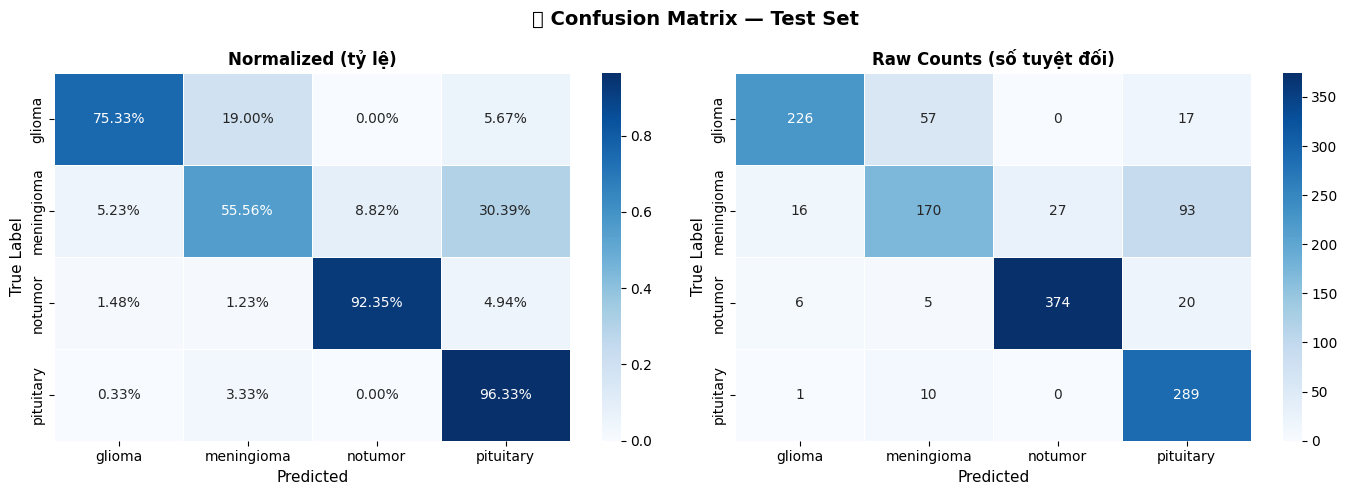

In [6]:
# Normalized
plot_confusion_matrix(
    y_true, y_pred, class_names,
    save_path=str(FIG_DIR / "confusion_matrix_normalized.png"),
    normalize=True,
)

# Raw counts
plot_confusion_matrix(
    y_true, y_pred, class_names,
    save_path=str(FIG_DIR / "confusion_matrix_counts.png"),
    normalize=False,
)

# ── Hiển thị cả 2 cạnh nhau ───────────────────────────────────── #
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm        = confusion_matrix(y_true, y_pred)
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes,
    [cm_norm, cm],
    [".2%", "d"],
    ["Normalized (tỷ lệ)", "Raw Counts (số tuyệt đối)"],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax, vmin=0)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.suptitle("🔲 Confusion Matrix — Test Set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_combined.png",
            dpi=150, bbox_inches="tight")
plt.show()

Cell 7 — ROC Curve & AUC

In [7]:
macro_auc = plot_roc_curve(
    y_true, y_probs, class_names,
    save_path=str(FIG_DIR / "roc_curve.png"),
)
print(f"\n  Macro AUC : {macro_auc:.4f}")

if macro_auc >= 0.98:
    print("  ✅ Xuất sắc")
elif macro_auc >= 0.95:
    print("  ✅ Tốt")
elif macro_auc >= 0.90:
    print("  🟡 Chấp nhận được")
else:
    print("  ⚠️  Cần cải thiện")

[Saved] ROC curve → outputs\figures\roc_curve.png

  Macro AUC : 0.9551
  ✅ Tốt


Cell 8 — Per-class Accuracy Bar Chart

In [8]:
plot_per_class_accuracy(
    y_true, y_pred, class_names,
    save_path=str(FIG_DIR / "per_class_accuracy.png"),
)

[Saved] Per-class accuracy → outputs\figures\per_class_accuracy.png


Cell 9 — Phân tích lỗi (Error Analysis)

[Error Analysis] Đang thu thập ảnh sai trực tiếp từ DataLoader...
   Tổng sai thống kê: 100 / 1311 (7.6%)

   Top 5 cặp nhầm lẫn nhiều nhất:
   True            Predicted        Count
   --------------------------------------
   glioma          meningioma          57
   meningioma      pituitary           20
   glioma          pituitary           17
   meningioma      notumor              4
   meningioma      glioma               2


C:\Users\Thang\AppData\Local\Temp\ipykernel_38360\663625182.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_38360\663625182.py:65: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "error_samples.png", dpi=150, bbox_inches="tight")
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


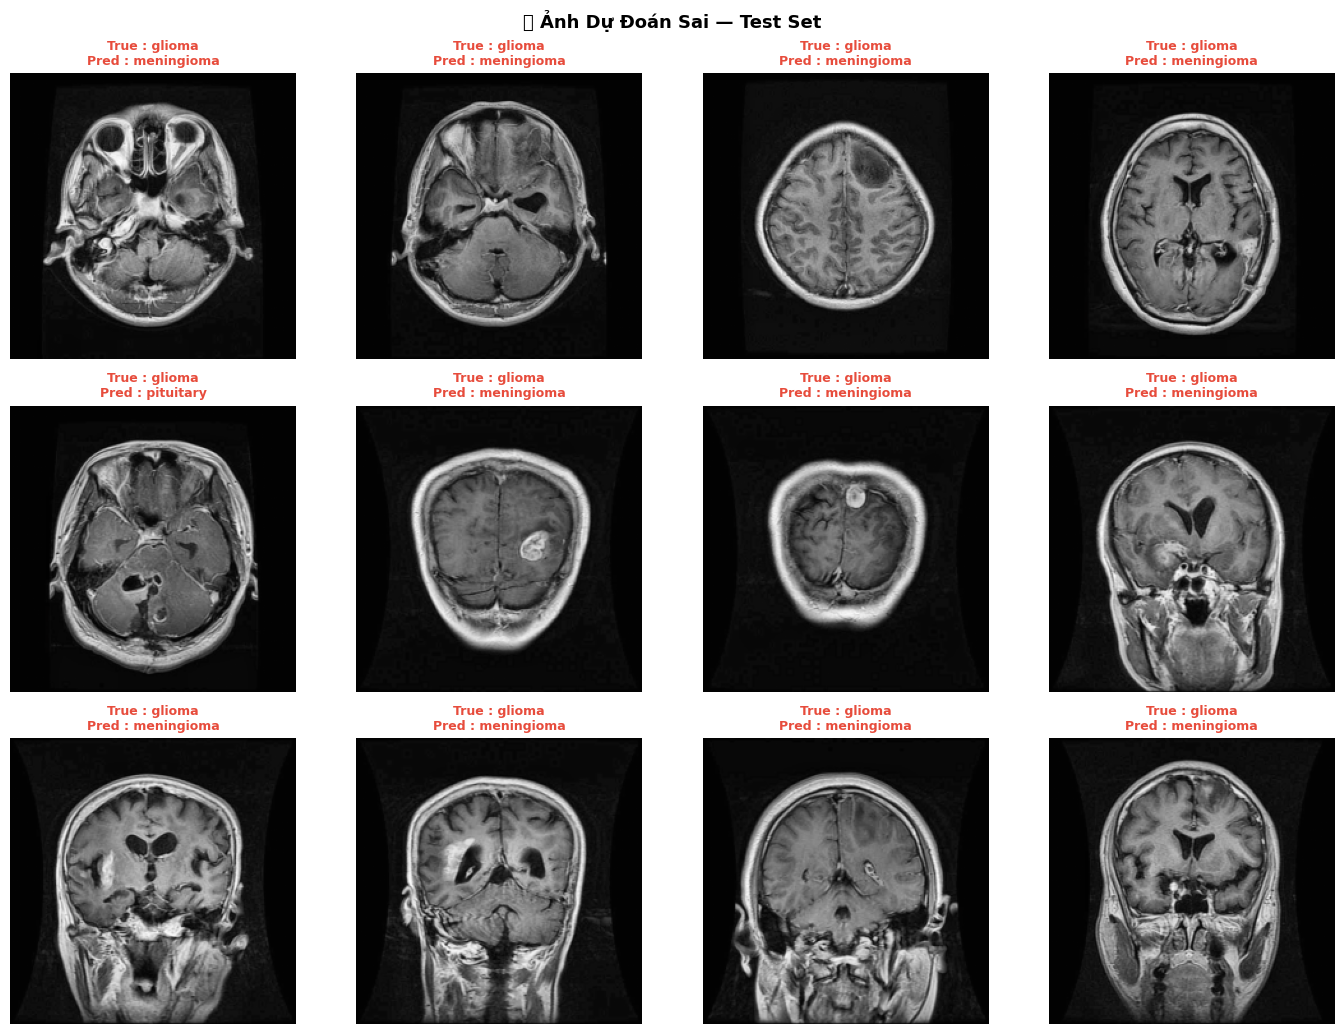

[Saved] → outputs\figures\error_samples.png


In [9]:
@torch.no_grad()
def get_exact_error_samples(model, loader, device, idx_to_class, n_max=100):
    """Quét loader và gom chính xác ảnh bị đoán sai mà không bị lệch chỉ số"""
    model.eval()
    errors = []
    
    for images, labels in loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        preds = outputs.argmax(dim=1).cpu().numpy()
        labels_np = labels.numpy()
        
        for i in range(len(preds)):
            if preds[i] != labels_np[i]:
                errors.append({
                    "image": images[i], # Lưu tensor ảnh gốc chưa đẩy lên GPU
                    "true_label": idx_to_class[labels_np[i]],
                    "pred_label": idx_to_class[preds[i]]
                })
                if len(errors) >= n_max:
                    return errors
    return errors

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

print("[Error Analysis] Đang thu thập ảnh sai trực tiếp từ DataLoader...")
errors = get_exact_error_samples(model, test_loader, device, idx_to_class)
n_errors = len(errors)
total = len(y_true)
print(f"   Tổng sai thống kê: {n_errors} / {total} ({n_errors/total*100:.1f}%)")

# ── Đếm cặp nhầm lẫn nhiều nhất ─────────────────────────────── #
from collections import Counter
pair_counter = Counter((e["true_label"], e["pred_label"]) for e in errors)
print(f"\n   Top 5 cặp nhầm lẫn nhiều nhất:")
print(f"   {'True':<15} {'Predicted':<15} {'Count':>6}")
print(f"   {'-'*38}")
for (true_cls, pred_cls), cnt in pair_counter.most_common(5):
    print(f"   {true_cls:<15} {pred_cls:<15} {cnt:>6}")

# ── Hiển thị ảnh lỗi ─────────────────────────────────────────── #
n_show = min(12, len(errors))
if n_show > 0:
    ncols = 4
    nrows = (n_show + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten() if nrows > 1 else [axes] if nrows == 1 else []

    for i, err in enumerate(errors[:n_show]):
        img = denormalize(err["image"]).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"True : {err['true_label']}\nPred : {err['pred_label']}", 
                          fontsize=9, color="#e74c3c", fontweight="bold")
        axes[i].axis("off")

    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"❌ Ảnh Dự Đoán Sai — Test Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "error_samples.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] → {FIG_DIR / 'error_samples.png'}")
else:
    print("✅ Tuyệt vời! Mô hình không đoán sai ảnh nào trên test set.")

Cell 10 — Tổng kết cuối

In [10]:
from sklearn.metrics import roc_auc_score

overall_acc = (y_pred == y_true).mean() * 100
f1_macro    = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("\n" + "="*55)
print("  🏁 KẾT QUẢ CUỐI CÙNG — TEST SET")
print("="*55)
print(f"  Overall Accuracy  : {overall_acc:.2f}%")
print(f"  F1 Macro          : {f1_macro:.4f}")
print(f"  F1 Weighted       : {f1_weighted:.4f}")
print(f"  Macro AUC         : {macro_auc:.4f}")
print(f"  Tổng lỗi          : {n_errors} / {total} ảnh")
print("-"*55)
print(f"  Checkpoint epoch  : {checkpoint['epoch']}")
print(f"  Val Loss (best)   : {checkpoint['val_loss']:.5f}")
print(f"  Val Acc  (best)   : {checkpoint['val_acc']:.2f}%")
print("-"*55)
print("  📊 Figures:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"     {f.name}")
print("  📝 Reports:")
for f in sorted(REPORT_DIR.glob("*")):
    print(f"     {f.name}")
print("="*55)

# Lưu summary ra CSV
summary = {
    "overall_acc" : round(overall_acc, 4),
    "f1_macro"    : round(f1_macro, 4),
    "f1_weighted" : round(f1_weighted, 4),
    "macro_auc"   : round(macro_auc, 4),
    "total_errors": n_errors,
    "total_samples": total,
    "best_epoch"  : int(checkpoint["epoch"]),
    "val_loss"    : round(float(checkpoint["val_loss"]), 5),
    "val_acc"     : round(float(checkpoint["val_acc"]), 4),
}
pd.DataFrame([summary]).to_csv(
    REPORT_DIR / "final_summary.csv", index=False
)
print(f"\n[Saved] Summary → {REPORT_DIR / 'final_summary.csv'}")


  🏁 KẾT QUẢ CUỐI CÙNG — TEST SET
  Overall Accuracy  : 80.78%
  F1 Macro          : 0.7939
  F1 Weighted       : 0.8039
  Macro AUC         : 0.9551
  Tổng lỗi          : 100 / 1311 ảnh
-------------------------------------------------------
  Checkpoint epoch  : 1
  Val Loss (best)   : 0.65060
  Val Acc  (best)   : 85.30%
-------------------------------------------------------
  📊 Figures:
     augmented_batch.png
     confusion_matrix_combined.png
     confusion_matrix_counts.png
     confusion_matrix_normalized.png
     error_samples.png
     per_class_accuracy.png
     roc_curve.png
  📝 Reports:
     classification_report.txt

[Saved] Summary → outputs\reports\final_summary.csv
